# Political Party Popularity Prediction
- Objective: Predict the popularity of political parties based on social media activity or survey data.
- Data: Social media posts, election results.
- Tasks: Clean and preprocess text data, and classify party sentiment using Logistic Regression or SVM.

In [58]:
import os
import pandas as pd

folder = r"C:\Users\ASUS\Desktop\project\data"
files = os.listdir(folder)

for file_name in files:
    if file_name.endswith('.csv'): 
        file_path = os.path.join(folder, file_name)
        print(f"File Name: {file_name}")
        
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path)
        print(df)

File Name: Election2008.csv
                                      Political Group  Total
0                  Communist Party of Nepal (Maoists)    220
1                                Nepali Congress (NC)    110
2                      Communist Party of Nepal (UML)    103
3                 Madhesi People's Rights Forum Nepal     52
4                       Tarai Madhes Loktantrik Party     20
5                                              Others     19
6                   Nepal Goodwill Party (Sadhvawana)      9
7         Communist Party of Nepal (Marxist Leninist)      8
8   National Democratic Party (Rastriya Prajatantr...      8
9                   People's Front Nepal (Janamorcha)      7
10                Communist Party of Nepal (Samyukta)      5
11  National Democratic Party Nepal (Rastriya Praj...      4
12                   Nepal Workers and Peasants Party      4
13      National People's Front (Rastriya Janamorcha)      4
14                                       Independents    

Then I have combine all the csv files using concat. 

In [59]:
combine_data = pd.DataFrame()
for file_name in files:
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder, file_name)
        df = pd.read_csv(file_path)
        combine_data = pd.concat([combine_data, df], ignore_index=True)
print(combine_data)

                                      Political Group  Total
0                  Communist Party of Nepal (Maoists)    220
1                                Nepali Congress (NC)    110
2                      Communist Party of Nepal (UML)    103
3                 Madhesi People's Rights Forum Nepal     52
4                       Tarai Madhes Loktantrik Party     20
5                                              Others     19
6                   Nepal Goodwill Party (Sadhvawana)      9
7         Communist Party of Nepal (Marxist Leninist)      8
8   National Democratic Party (Rastriya Prajatantr...      8
9                   People's Front Nepal (Janamorcha)      7
10                Communist Party of Nepal (Samyukta)      5
11  National Democratic Party Nepal (Rastriya Praj...      4
12                   Nepal Workers and Peasants Party      4
13      National People's Front (Rastriya Janamorcha)      4
14                                       Independents      2
15                      

Here I have saved the combined data into folder "data" and named it as "Combine Election Result".

In [ ]:
combine_data.to_csv("data/Combine Election Result", index=False)

Then I have accessed that combine data for analysing.

In [60]:
df = pd.read_csv("data/Combine Election Results")
df

,Year,Political Group,Total
0,2008,Communist Party of Nepal (Maoists),220
1,2008,Nepali Congress (NC),110
2,2008,Communist Party of Nepal (UML),103
3,2008,Madhesi People's Rights Forum Nepal,52
4,2008,Tarai Madhes Loktantrik Party,20
5,2008,Others,19
6,2008,Nepal Goodwill Party (Sadhvawana),9
7,2008,Communist Party of Nepal (Marxist Leninist),8
8,2008,National Democratic Party (Rastriya Prajatantr...,8
9,2008,People's Front Nepal (Janamorcha),7


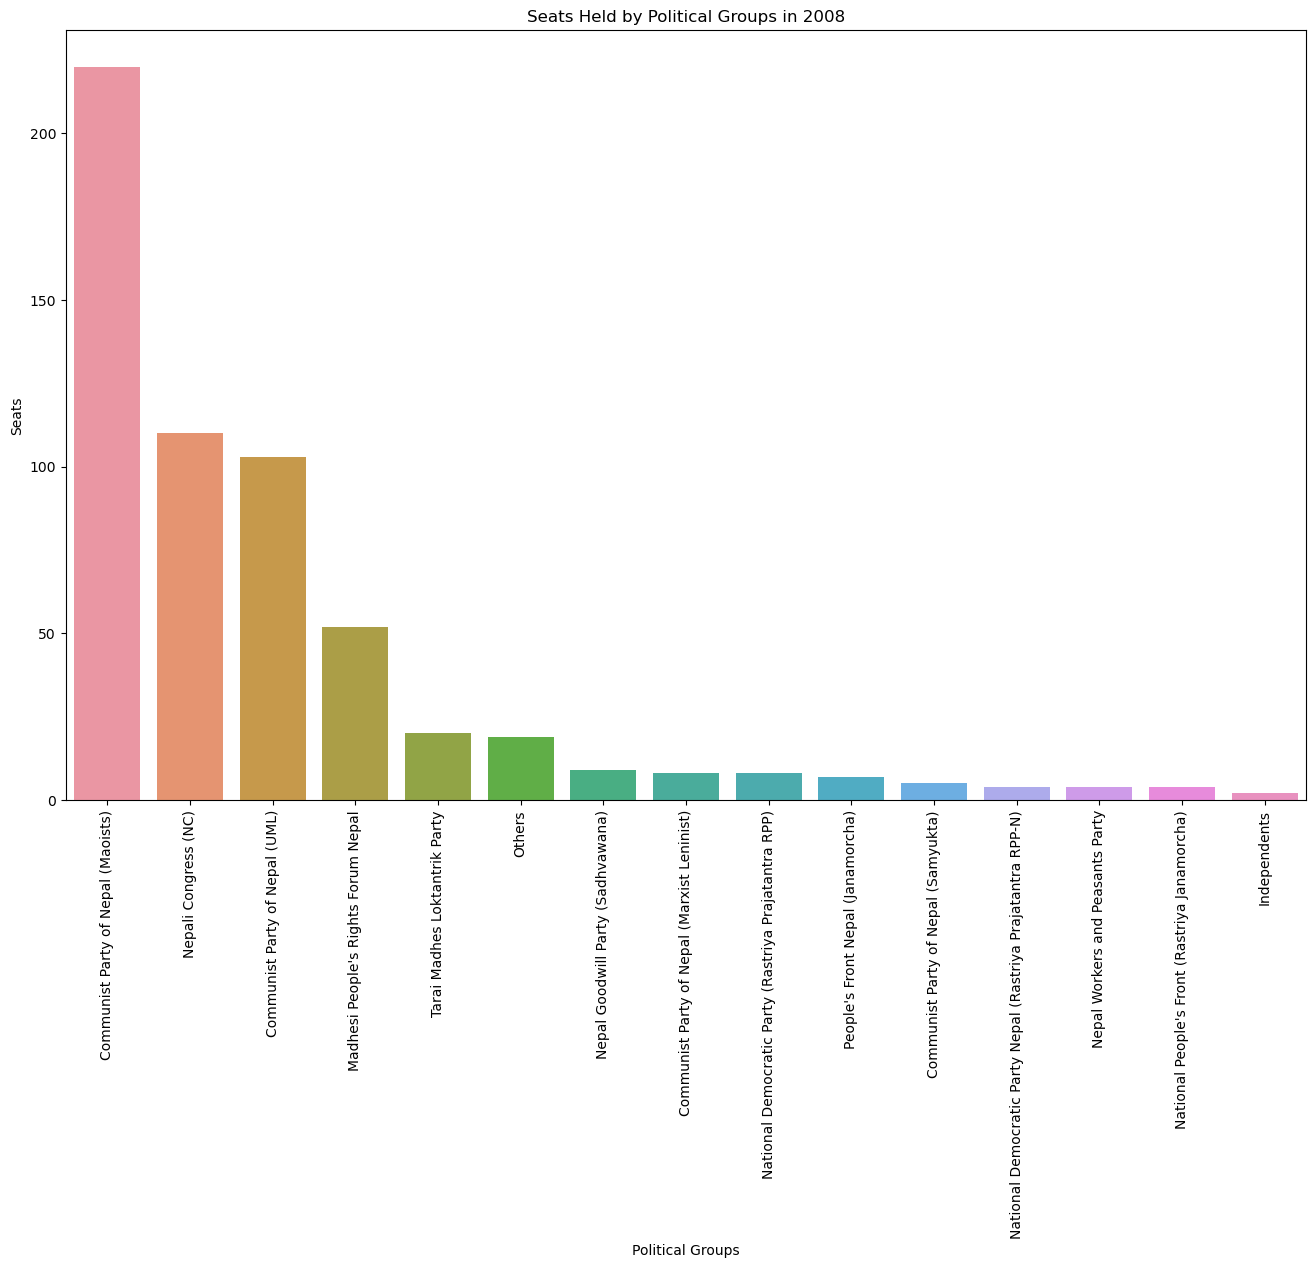

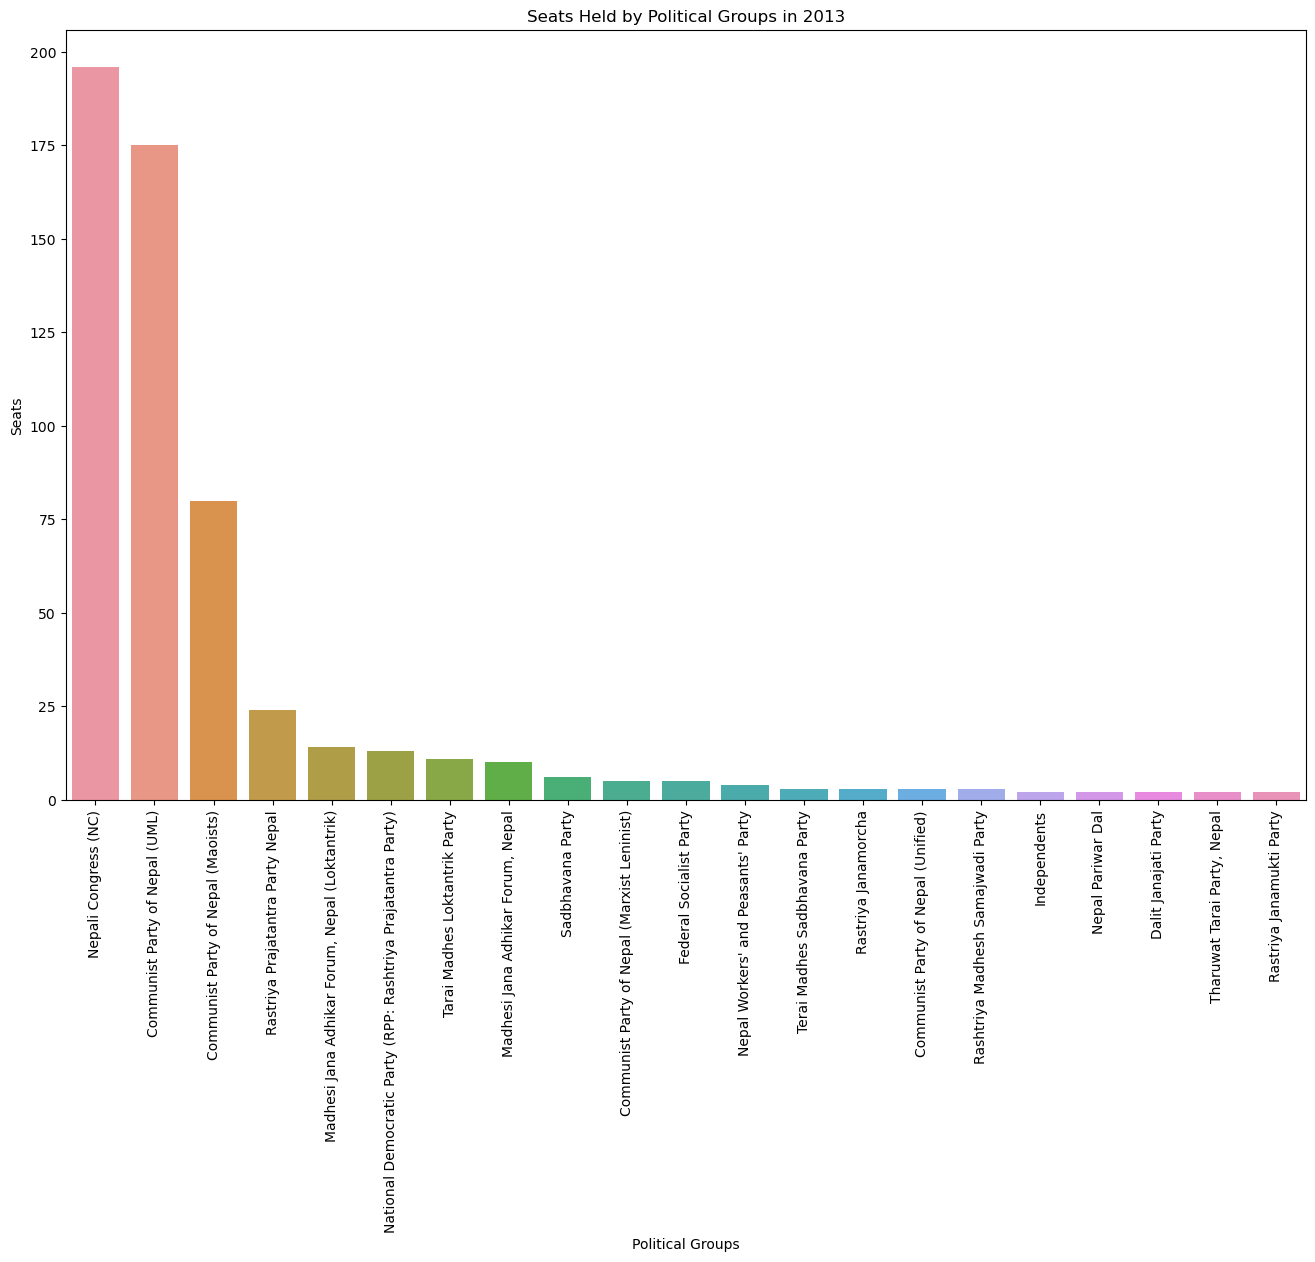

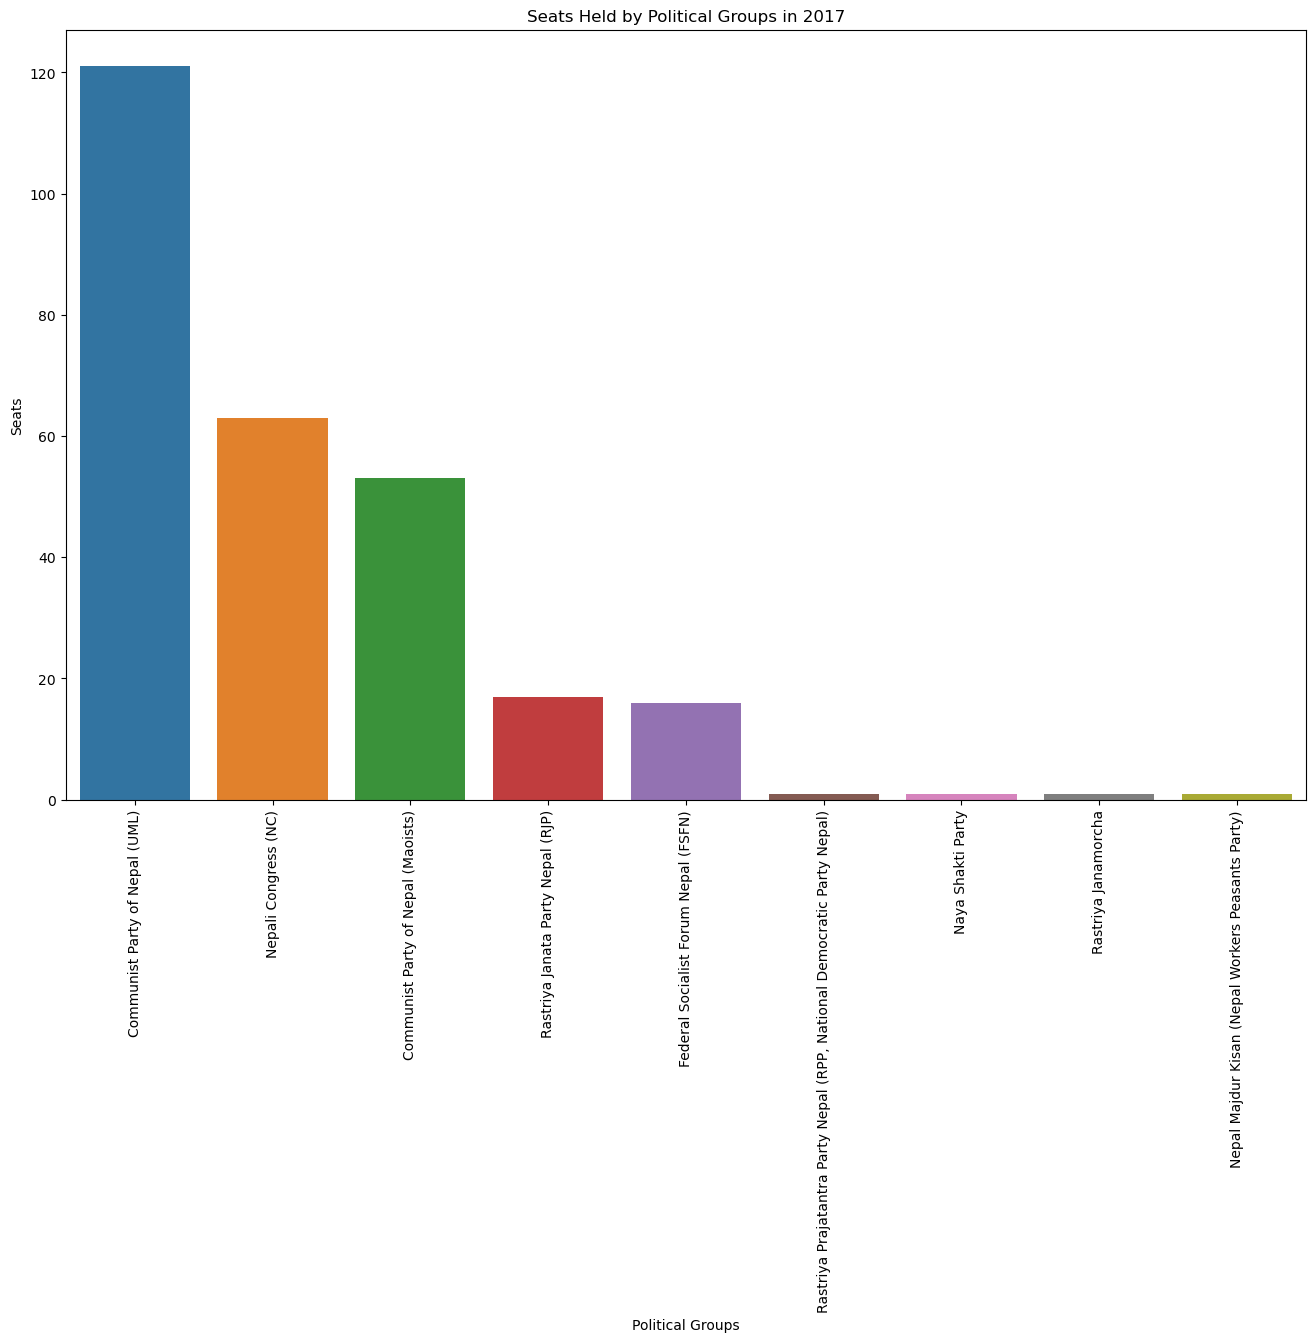

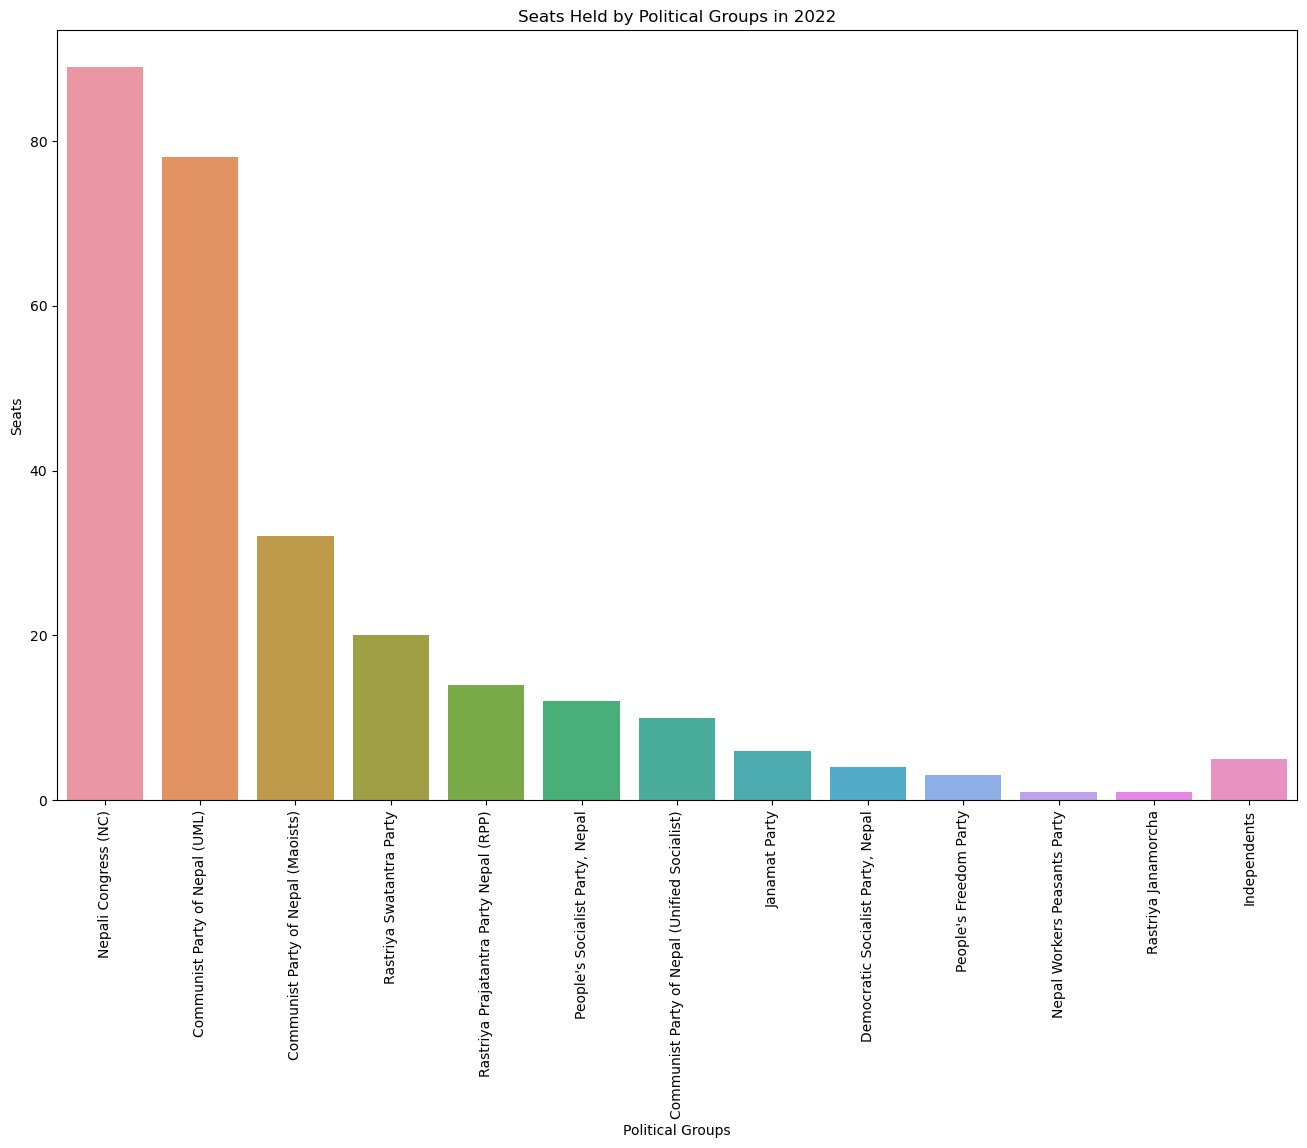

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_seats_by_year(df, year):
    df_year = df[df['Year'] == year]
    
    plt.figure(figsize=(16, 10))
    
    sns.barplot(x='Political Group', y='Total', data=df_year)
    
    plt.title(f'Seats Held by Political Groups in {year}')
    plt.xlabel('Political Groups')
    plt.ylabel('Seats')
    plt.xticks(rotation=90)  # Rotate x labels for better readability
    
    plt.show()

years = [2008, 2013, 2017, 2022]

for year in years:
    plot_seats_by_year(df, year)

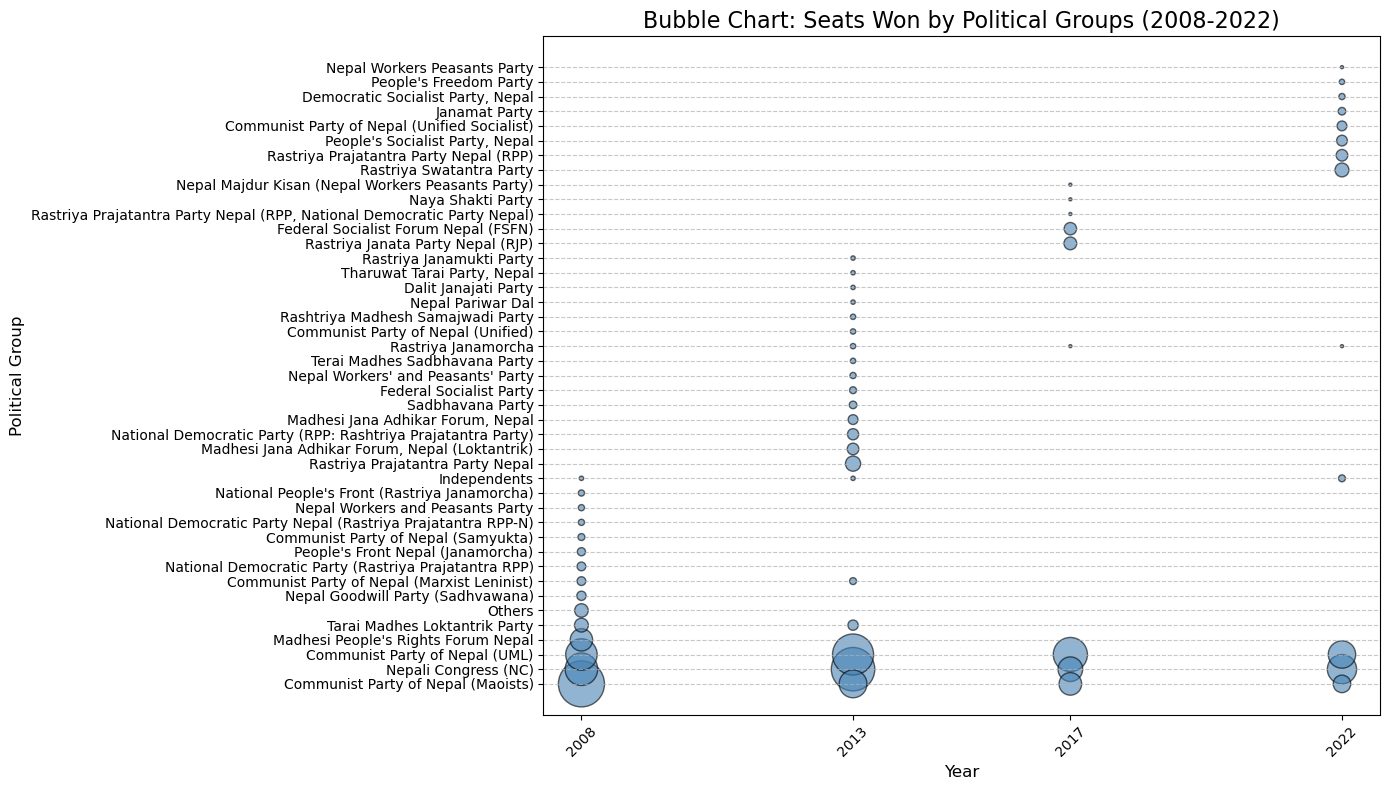

In [62]:

# Plot Bubble Chart
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    df['Year'],
    df['Political Group'],
    s=df['Total'] * 5,  # Bubble size (scaled)
    alpha=0.6,
    color="steelblue",
    edgecolor="black"
)

# Labels and title
plt.title("Bubble Chart: Seats Won by Political Groups (2008-2022)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Political Group", fontsize=12)
plt.xticks(df['Year'].unique(), rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

Here I have created pie chart that shows the seat percentage of parties of each election. Here I have not created fuction rather just used for loop in the data and made temporary dataframe called pie_data that stores the value of that current year of election. The pie chart uses "total" as its main data for showing the seat percentage and Political Group for showing the party names.

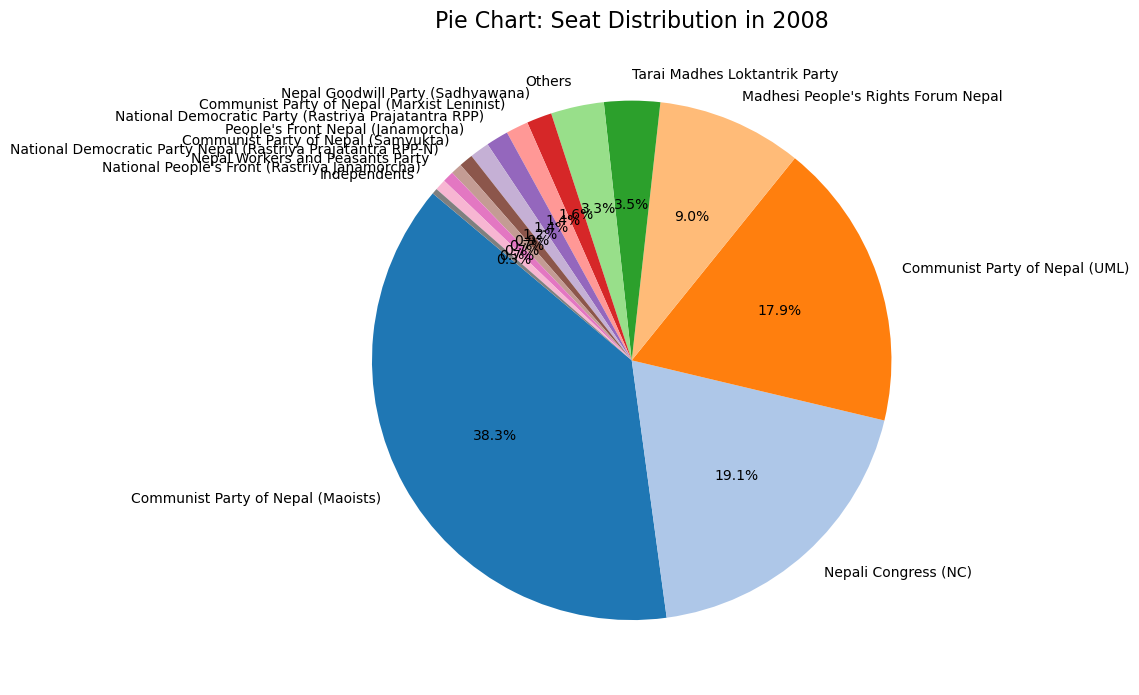

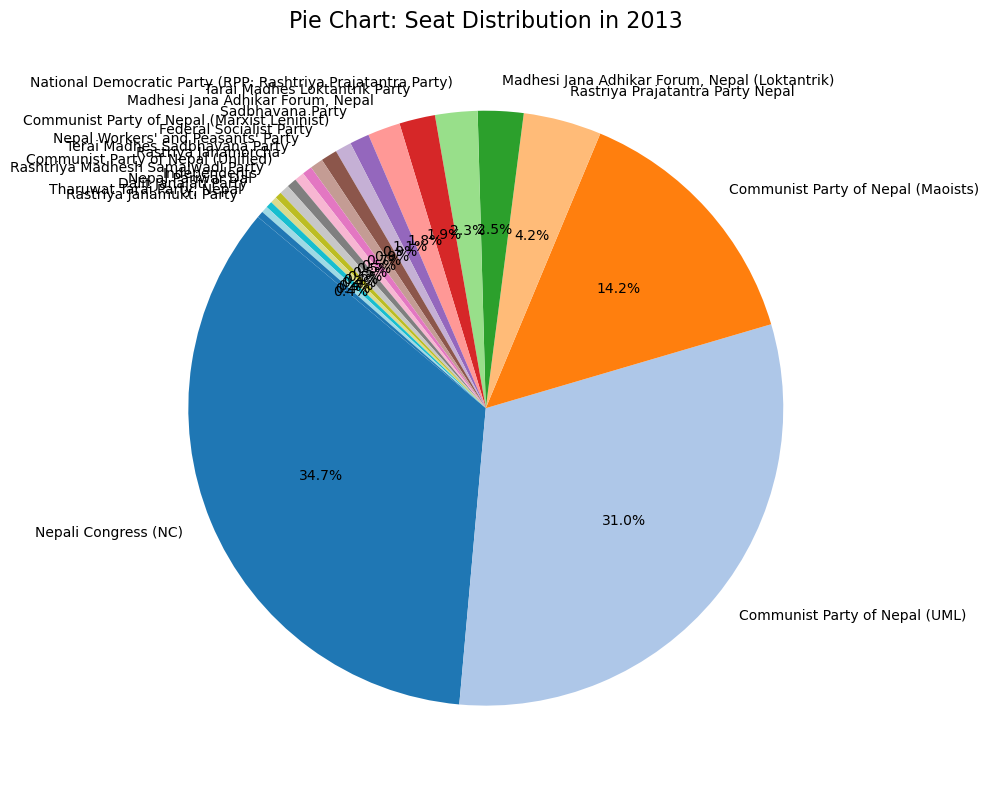

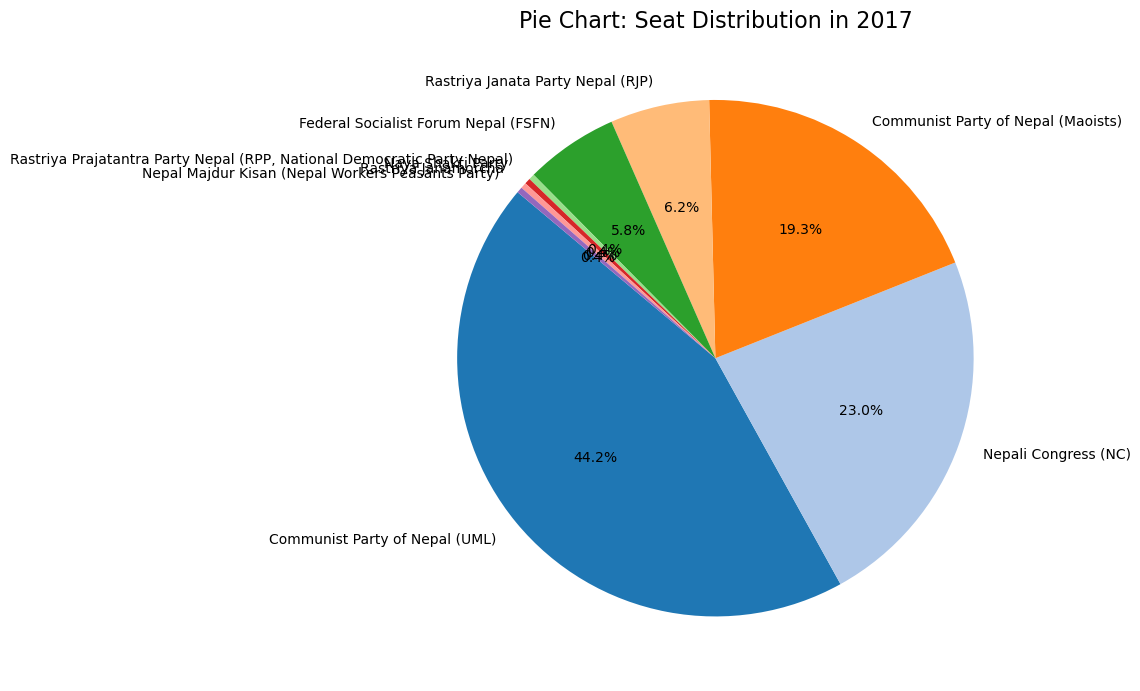

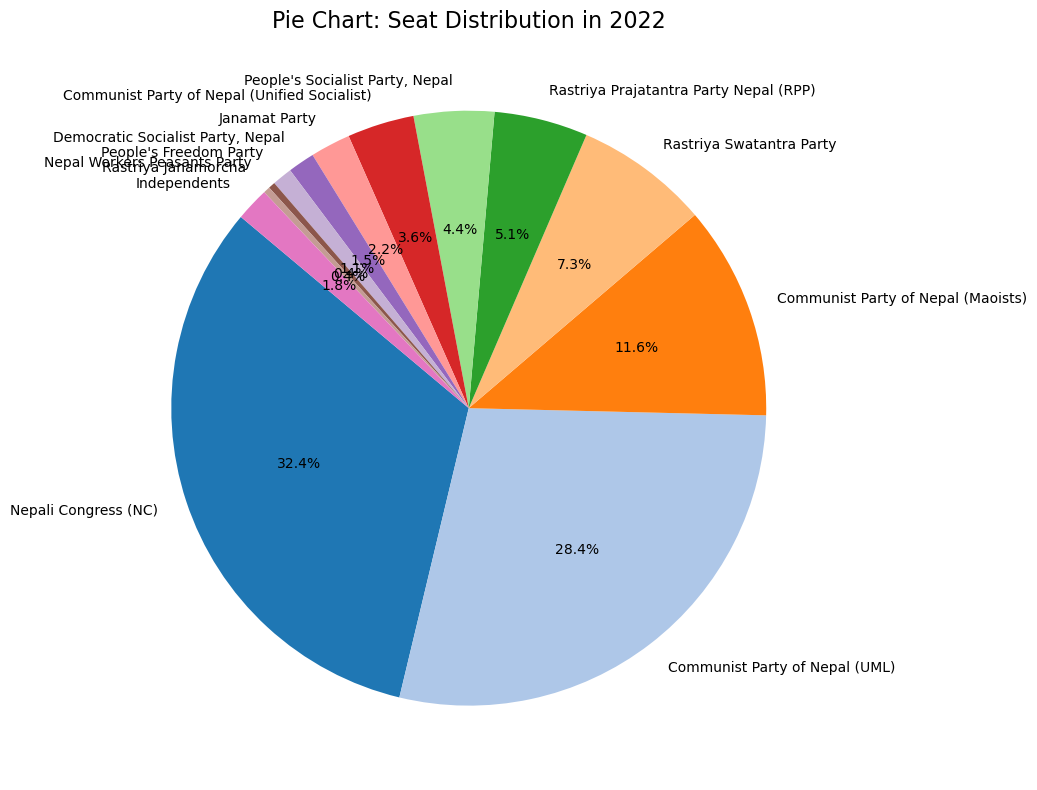

In [63]:
unique_years = df['Year'].unique()
for year in unique_years:
    pie_data = df[df['Year'] == year]

    plt.figure(figsize=(10, 8))
    plt.pie(
        pie_data['Total'], 
        labels=pie_data['Political Group'], 
        autopct="%1.1f%%", 
        startangle=140, 
        colors=plt.cm.tab20.colors
    )
    plt.title(f"Pie Chart: Seat Distribution in {year}", fontsize=16)
    plt.tight_layout()
    plt.show()

In this I have just created the line plot for three major parties since 2008 till now. This shows their trends of how many seats they have won since 2008 till now. 

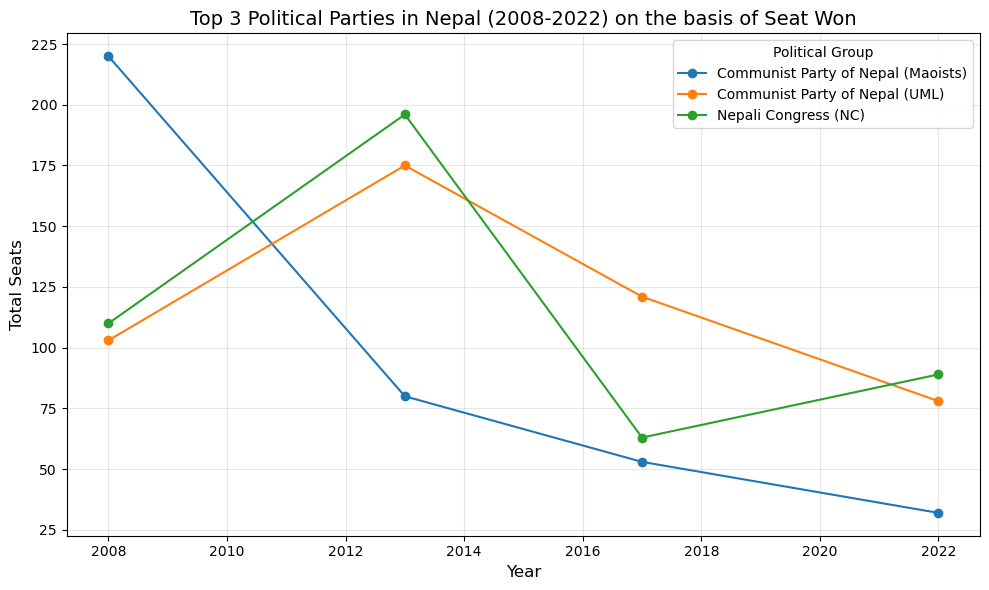

In [64]:
df = pd.read_csv("data/Combine Election Results")
top_three_parties = [
    "Communist Party of Nepal (Maoists)",
    "Nepali Congress (NC)",
    "Communist Party of Nepal (UML)"
]
parties = df[df["Political Group"].isin(top_three_parties)]

plot_data = parties.pivot(index="Year", columns="Political Group", values="Total")

plt.figure(figsize=(10, 6))
for column in plot_data.columns:
    plt.plot(plot_data.index, plot_data[column], marker="o", label=column)

plt.title("Top 3 Political Parties in Nepal (2008-2022) on the basis of Seat Won", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Seats", fontsize=12)
plt.legend(title="Political Group")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Now I will be using sentiment data to show the popularity of top three parties.

In [15]:
import pandas as pd

df = pd.read_excel('sentiment/updated_party_comments_2.xlsx')
df

,Year,Party,Comment,Sentiment,source,Result,Popularity
0,2008,Nepali Congress,Potential game-changer,Positive,social media,Lose,Not Popular
1,2008,Nepali Congress,Great,Positive,news outlet,Lose,Not Popular
2,2008,Nepali Communist Party (UML),Visionary approach to governance,Positive,news outlet,Lose,Not Popular
3,2008,Nepali Congress,Committed to democracy,Positive,news outlet,Lose,Not Popular
4,2008,Nepali Communist Party (Maoist),Championing people rights,Positive,youtube,Win,Popular
...,...,...,...,...,...,...,...
195,2022,Nepali Communist Party (UML),Strong commitment to national interests,Positive,youtube,Lose,Not Popular
196,2022,Nepali Communist Party (Maoist),Betraying original principles,Negative,news outlet,Lose,Not Popular
197,2022,Nepali Communist Party (UML),Political hypocrisy exposed,Negative,news outlet,Lose,Not Popular
198,2022,Nepali Communist Party (UML),Breakthrough in national development,Positive,social media,Lose,Not Popular


Here I have shown the distribution of positive and negative sentiment.

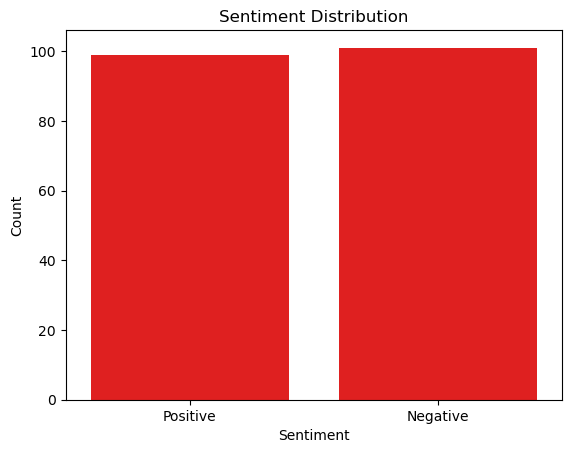

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Sentiment', color='red')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

These are the pre-processing and feature engineering steps that I have taken. I have mapped categorical data of sentiment as numerical values. I have done same for result and Popularity as well. After that I have changed all the characters of comment into lower case. Then I have used regex to remove any non-alpha numeric values that are there in the comment. 

In [17]:
df['Sentiment'] = df['Sentiment'].map({"Positive": 1, "Negative": 0}) # mapping sentiment

df['Result'] = df['Result'].map({"Win": 1, "Lose": 0})

df['Popularity'] = df['Popularity'].map({"Popular": 1, "Not Popular": 0})

df['Comment'] = df['Comment'].str.lower()

df['Comment'] = df['Comment'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

In [18]:
df

,Year,Party,Comment,Sentiment,source,Result,Popularity
0,2008,Nepali Congress,potential gamechanger,1,social media,0,0
1,2008,Nepali Congress,great,1,news outlet,0,0
2,2008,Nepali Communist Party (UML),visionary approach to governance,1,news outlet,0,0
3,2008,Nepali Congress,committed to democracy,1,news outlet,0,0
4,2008,Nepali Communist Party (Maoist),championing people rights,1,youtube,1,1
...,...,...,...,...,...,...,...
195,2022,Nepali Communist Party (UML),strong commitment to national interests,1,youtube,0,0
196,2022,Nepali Communist Party (Maoist),betraying original principles,0,news outlet,0,0
197,2022,Nepali Communist Party (UML),political hypocrisy exposed,0,news outlet,0,0
198,2022,Nepali Communist Party (UML),breakthrough in national development,1,social media,0,0


Here I have combine comment and source in the new column called "Combine_text". 

In [19]:
df["Combine_text"] = df["Comment"] + ' ' + df["source"]

In [20]:
df

,Year,Party,Comment,Sentiment,source,Result,Popularity,Combine_text
0,2008,Nepali Congress,potential gamechanger,1,social media,0,0,potential gamechanger social media
1,2008,Nepali Congress,great,1,news outlet,0,0,great news outlet
2,2008,Nepali Communist Party (UML),visionary approach to governance,1,news outlet,0,0,visionary approach to governance news outlet
3,2008,Nepali Congress,committed to democracy,1,news outlet,0,0,committed to democracy news outlet
4,2008,Nepali Communist Party (Maoist),championing people rights,1,youtube,1,1,championing people rights youtube
...,...,...,...,...,...,...,...,...
195,2022,Nepali Communist Party (UML),strong commitment to national interests,1,youtube,0,0,strong commitment to national interests youtube
196,2022,Nepali Communist Party (Maoist),betraying original principles,0,news outlet,0,0,betraying original principles news outlet
197,2022,Nepali Communist Party (UML),political hypocrisy exposed,0,news outlet,0,0,political hypocrisy exposed news outlet
198,2022,Nepali Communist Party (UML),breakthrough in national development,1,social media,0,0,breakthrough in national development social media


Then I vectorized combine_text column which will help me get numerical data for words that will be used in predicting popularity along with another feature. 

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_tfidf = vectorizer.fit_transform(df["Combine_text"])



This is the another feature that I will be using. I have stored the data as DataFrame and used values to convert it into numpy array. 

In [34]:
numerical_features = df[['Sentiment']].values

In [35]:
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split

X_combined = hstack([X_tfidf, numerical_features])
y = df["Popularity"]

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=32)

In [36]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [37]:
df['Predicted Popularity'] = model.predict(X_combined)
df['Predicted Popularity'] = df['Predicted Popularity'].map({1: "Popular", 0: "Not Popular"})

In [38]:
party_popularity = df.groupby('Party')['Predicted Popularity'].agg(lambda x: x.mode()[0]).reset_index()
party_popularity

,Party,Predicted Popularity
0,Nepali Communist Party (Maoist),Not Popular
1,Nepali Communist Party (UML),Not Popular
2,Nepali Congress,Not Popular


Accuracy: 0.6000
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.96      0.74        24
           1       0.50      0.06      0.11        16

    accuracy                           0.60        40
   macro avg       0.55      0.51      0.43        40
weighted avg       0.56      0.60      0.49        40

ROC-AUC: 0.4570


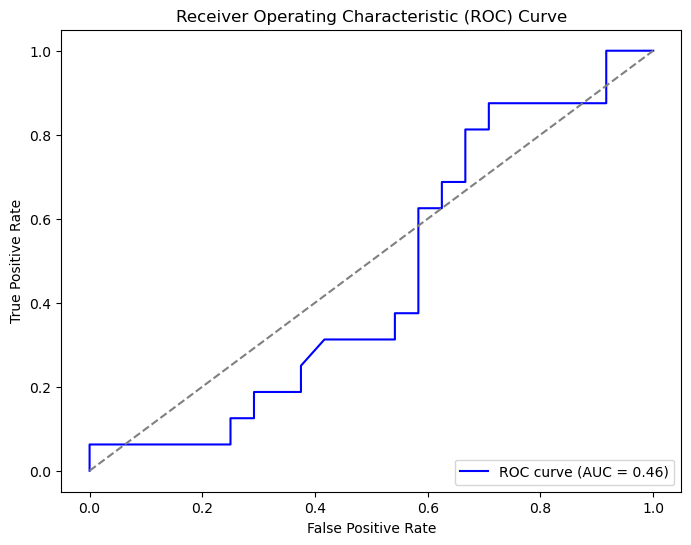

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict sentiment on the test set
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')


print("Classification Report:")
print(classification_report(y_test, y_pred))

y_prob = model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class (1)
roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC: {roc_auc:.4f}')

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


# using svm

In [40]:
from sklearn.svm import SVC

model = SVC(probability=True)
model.fit(X_train, y_train)

SVC(probability=True)

In [41]:
df['Predicted Popularity'] = model.predict(X_combined)
df['Predicted Popularity'] = df['Predicted Popularity'].map({1: "Popular", 0: "Not Popular"})

In [42]:
party_popularity = df.groupby('Party')['Predicted Popularity'].agg(lambda x: x.mode()[0]).reset_index()
party_popularity

,Party,Predicted Popularity
0,Nepali Communist Party (Maoist),Not Popular
1,Nepali Communist Party (UML),Not Popular
2,Nepali Congress,Not Popular


Accuracy: 0.6000
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.96      0.74        24
           1       0.50      0.06      0.11        16

    accuracy                           0.60        40
   macro avg       0.55      0.51      0.43        40
weighted avg       0.56      0.60      0.49        40

ROC-AUC: 0.5352


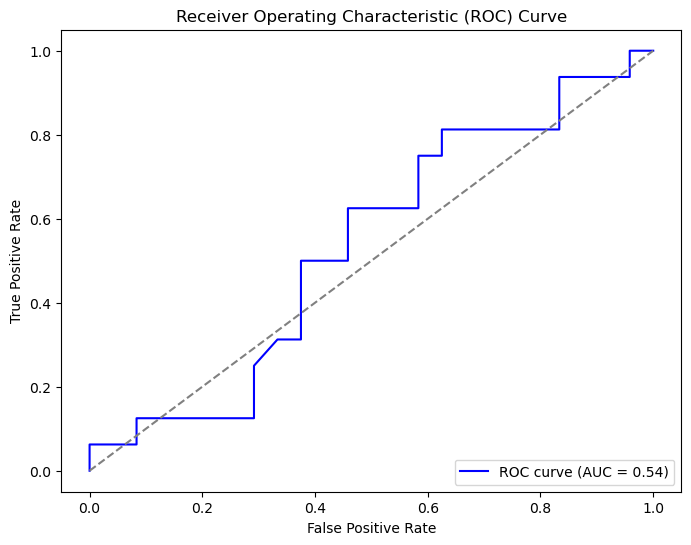

In [43]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict sentiment on the test set
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')


print("Classification Report:")
print(classification_report(y_test, y_pred))

y_prob = model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class (1)
roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC: {roc_auc:.4f}')

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


inference

In [54]:
import re

comments = [
    "Party is very excellent",
    "Next time they come they will get sandals",
    "Everyone is very corrupt"
]

sources = ["youtube", 'news outlet', 'social media']

comments_clean = [comment.lower() for comment in comments]
comments_clean = [re.sub(r'[^a-zA-Z0-9\s]', '', comment) for comment in comments_clean]

new_combined = [comments_clean[i] + ' ' + sources[i] for i in range(len(comments))]

X_new_tfidf = vectorizer.transform(new_combined)

new_numerical_features = [[0]] * len(comments)

X_new_combined = hstack([X_new_tfidf, new_numerical_features])

new_predictions = model.predict(X_new_combined)

predicted_popularity = ["Popular" if pred == 1 else "Not Popular" for pred in new_predictions]

for comment, popularity in zip(comments, predicted_popularity):
    print(f"Comment: {comment}")
    print(f"Predicted Popularity: {popularity}")
    print("-" * 50)


Comment: Party is very excellent
Predicted Popularity: Popular
--------------------------------------------------
Comment: Next time they come they will get sandals
Predicted Popularity: Not Popular
--------------------------------------------------
Comment: Everyone is very corrupt
Predicted Popularity: Not Popular
--------------------------------------------------


using random forest

In [44]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

In [45]:
df['Predicted Popularity'] = model.predict(X_combined)
df['Predicted Popularity'] = df['Predicted Popularity'].map({1: "Popular", 0: "Not Popular"})

In [46]:
party_popularity = df.groupby('Party')['Predicted Popularity'].agg(lambda x: x.mode()[0]).reset_index()
party_popularity

,Party,Predicted Popularity
0,Nepali Communist Party (Maoist),Not Popular
1,Nepali Communist Party (UML),Not Popular
2,Nepali Congress,Not Popular


evalutaing model

Accuracy: 0.5250
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.79      0.67        24
           1       0.29      0.12      0.17        16

    accuracy                           0.53        40
   macro avg       0.43      0.46      0.42        40
weighted avg       0.46      0.53      0.47        40

ROC-AUC: 0.5352


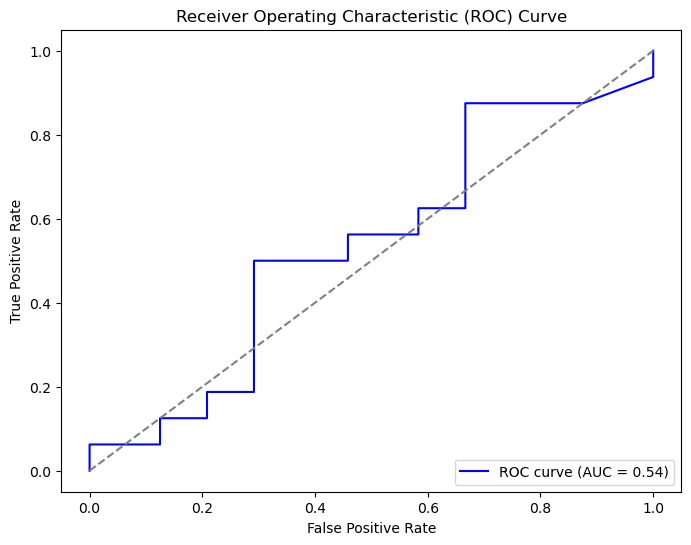

In [47]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict sentiment on the test set
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')


print("Classification Report:")
print(classification_report(y_test, y_pred))

y_prob = model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class (1)
roc_auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC: {roc_auc:.4f}')

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()